In [1]:
import numpy as np

from skfem import Basis, ElementVector, ElementComposite, FacetBasis
from skfem.assembly import asm, BilinearForm, LinearForm
from skfem.helpers import grad, sym_grad, div, dot, ddot, trace, eye
from skfem import MeshQuad1, ElementQuad0, ElementQuad1, ElementQuad2, ElementQuadRT0, ElementTriP1, MeshTri
from skfem import ElementLineP2, ElementLineP1, ElementLineP0, MeshLine
from skfem.visuals.matplotlib import draw

import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix, lil_matrix
from scipy.integrate import solve_ivp
from scipy.sparse.linalg import splu, spsolve

import ipywidgets as widgets
import time

import autograd.numpy as anp
from autograd import elementwise_grad

import solve_nivp
from solve_nivp.contact import build_impulse_contact

## Data

In [2]:
L = 1e-6#.00001 #[m]

ρf = 1000 * L**3
ρs = 2500 * L**3

Kf = 2.2e9 * L**1
Ks = 80e9 * L**1
nu = .15
φ = .2
α = .6

turt = 1 # 1 straight pores, should be larger than 1

k_vv = 1e18*L**3
k_vu = 1e18*L**3
k_r = 1e21*L**3
ηs = 9e-1

k = 1e-18 * L**-2
μf = 1e-3 * L**1

Kb = Ks*(1-α)
G = 3/2*Kb*(1-2*nu)/(1+nu)
M = ((α-φ)/Ks + φ/Kf)**-1
# ρ11 = (1 - φ) * ρs + φ * ρf
# ρ12 = ρf
# ρ22 = ρs / φ + ρf / φ**2


ρ11 = (1 - φ) * ρs + (turt - 1) * φ * ρf
ρ22 = turt * φ * ρf
ρ12 = -(turt - 1) * φ * ρf 
# print(ρ11,ρ22,ρ12)
Δ = ρ11*ρ22 - ρ12**2
mu = G
lam = Kb - 2*G/3
b = (k / μf)**-1

# robin_left = (k_vv*0, 0, k_vu*0, 0, k_r)
robin_left = (k_vv, k_vv, k_vu, k_vu, k_r)
robin_right = (k_vv, 0, k_vu, 0, k_r)

bc_dofs = {
    'u1': {'left': 0.},
    # # 'v1': {'left': 0.},
    'u2': {'left': 0.},
    # # 'v2': {'left': 0.},
    # 'u1': {'left': 0.,'right': 0.},
    # # 'v1': {'left': 0.,'right': 0.},
    # 'p': {'left': 0.,'right': 0.},
}


Dc=.10 /1000/L #mm
Dmu=-.1
mu_res=.5
s11_eff_0 = 4*1e6 * L**1
friction_sides = ["right"]
# friction_sides = []

# Domain
D = 1000. #[m]

Ku = Kb + α**2*M
rho_b = (1-φ)*ρs + φ*ρf
vw = np.sqrt((Ku + 4/3*mu)/rho_b)
print("Δ:",Δ)
print("α:",α)
print("Kb:", Kb*1e-9*L**-1)
print("G:", G*1e-9*L**-1)
print("M/Kb:",M/Kb)
Cm = np.array([[Kb + 4/3*G, α*M],[α*M, M]])
Rm = np.array([[ρ11, ρ12],[ρ12, ρ22]])
tmp = np.linalg.solve(Rm, Cm)  # = Rho^{-1} C
c2, vecs = np.linalg.eig(tmp)
vw1, vw2 = np.sqrt(c2)

print("undrained wave velocity", vw * L**1)
print("wave velocities", vw1 * L**1, vw2 * L**1)
chy = k / μf / M**-1
print("tch_mech:", (D/2)/ vw1 / L, "[s]", (D/2)/ vw2 / L, "[s]")
print("tch_diff:", (D/L/2)**2/chy, "[s]")
print("G/D:", G/(D/L), "dFr/ds", -Dmu*s11_eff_0/Dc )
EQslip = -G/(D /L)> Dmu*s11_eff_0/Dc
print("EQ like slip:", EQslip)
if EQslip:
    expd_slip = -Dmu*0.99*s11_eff_0/G*D/L
    print("    Expected seismic slip [m]:",expd_slip*L)

Δ: 3.9999999999999995e-31
α: 0.6
Kb: 32.00000000000001
G: 29.217391304347828
M/Kb: 0.32582938388625593
undrained wave velocity 5827.445886863148
wave velocities 5556.573891512604 7532.2937329558945
tch_mech: 0.08998350598085733 [s] 0.06638084197544766 [s]
tch_diff: 23977272727.272724 [s]
G/D: 2.9217391304347826e-05 dFr/ds 0.004
EQ like slip: True
    Expected seismic slip [m]: 0.013553571428571429


In [3]:
point_source_loc = np.array([[.0]])
point_source_Q0 = np.array([[-1e-10]])

## Mesh

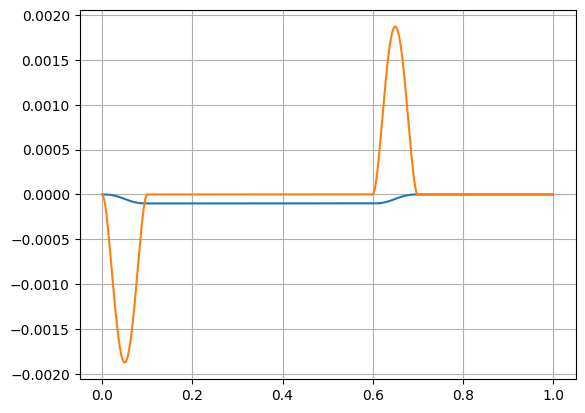

In [4]:
def smoothstep_quintic(x):
    # x assumed in [0,1]
    return x*x*x*(x*(x*6 - 15) + 10)

def smooth_step(t, t0, tau):
    x = (t - t0) / tau
    x = anp.clip(x, 0.0, 1.0)
    return smoothstep_quintic(x)

def smooth_pulse(t, t_start, t_end, tau = 1e-4):
    return (1 - smooth_step(t, t_end, tau)) * smooth_step(t, t_start, tau)
# dq_pulse = agrad(q_pulse, argnum=0)
dsmooth_pulse = elementwise_grad(smooth_pulse, argnum=0)

def qv(t, t_start, t_end, tau=1e-4):
    q0 = point_source_Q0
    return q0[:] * smooth_pulse(t, t_start, t_end, tau)/L**1  # (ns, len(t)) if t is vector

def dqv(t, t_start, t_end, tau=1e-4):
    q0 = point_source_Q0
    return q0[:] * dsmooth_pulse(t, t_start, t_end, tau)/L**1 # (ns, len(t))

tmax = 1.
tau = .1
ts = np.linspace(0, tmax, 1000, endpoint=True)
qs = qv(ts, t_start = 0, t_end = 3*tmax/5, tau = tau)
dqs = dqv(ts, t_start = 0, t_end = 3*tmax/5, tau = tau)
plt.plot(ts,qs.T)
plt.plot(ts,dqs.T)
plt.grid(True)
plt.show()
q = lambda t: qv(t, t_start = 0, t_end = 5*tmax/3, tau = tau).squeeze()
dq = lambda t: dqv(t, t_start = 0, t_end = 5*tmax/3, tau = tau).squeeze()

In [5]:
# Domain setup
xmin, xmax = -D/2, D/2 # [m]

xmin_d, xmax_d = xmin/L, xmax/L

bnd_labels = {
    'left': lambda x: np.isclose(x[0], xmin_d),
    'right': lambda x: np.isclose(x[0], xmax_d),
    }

In [6]:
def meshline_geometric_symmetric(x0, xL, N, q):
    if N % 2 != 0:
        raise ValueError("N must be even for symmetric grading")
    L = xL - x0
    N2 = N // 2

    if abs(q - 1.0) < 1e-14:
        return np.linspace(x0, xL, N + 1)

    h0 = (L/2) * (q - 1.0) / (q**N2 - 1.0)
    h = h0 * q**np.arange(N2)
    x_left = np.concatenate(([0.0], np.cumsum(h)))  # includes 0 and (about) L/2

    # mirror nodes about L/2: exclude the midpoint to avoid duplication
    x_right = L - x_left[-2::-1]  # start from node before midpoint down to 0

    x = x0 + np.concatenate([x_left, x_right])
    x[-1] = xL
    return x

-500000000.0 500000000.0


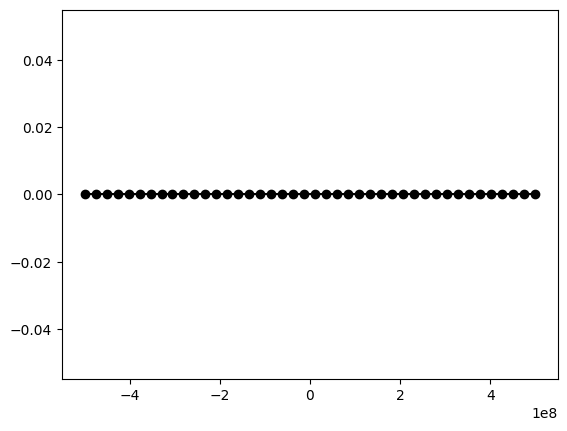

In [7]:
mesh_elements = 40+1
xcoords = np.linspace(xmin_d, xmax_d, mesh_elements + 1)
# xcoords = meshline_geometric_symmetric(xmin_d, xmax_d, mesh_elements, 1.15)
print(np.amin(xcoords),np.amax(xcoords))
mesh = MeshLine(xcoords)

mesh = mesh.with_boundaries(bnd_labels)
left_facets = mesh.boundaries['left']
right_facets = mesh.boundaries['right']

draw(mesh)
plt.show()

## Const. law

In [8]:
def sij_core(E_kl, x_type):
    dim = E_kl.shape[-1]
    if dim == 2:
        batch_shape = E_kl.shape[:-2]
        E_kl_3D = np.zeros(batch_shape + (3, 3), dtype=E_kl.dtype)
        E_kl_3D[..., :dim, :dim] = E_kl
    elif dim == 3:
        E_kl_3D = E_kl
    else:
        raise ValueError("dim must be 1, 2 or 3")
    
    trE = np.trace(E_kl_3D, axis1=-2, axis2=-1)[..., None, None]
    I = np.eye(3, dtype=E_kl_3D.dtype)

    s3 = 2.0 * mu * E_kl_3D + lam * trE * I  # fully broadcasted

    return s3[..., :dim, :dim]   # slice back if dim==2

def Sij(E, x_type):
    """Wrapper that preserves the axis order of E."""
    E = np.asarray(E)
    if E.ndim < 2 or E.shape[0] != E.shape[1] or E.shape[0] not in (2, 3):
        raise ValueError(f"Expected (2,2,...) or (3,3,...), got {E.shape}")

    # move matrix axes (0,1) → (-2,-1), compute, move back
    E_last = np.moveaxis(E, (0, 1), (-2, -1))
    S_last = sij_core(E_last, x_type)
    return np.moveaxis(S_last, (-2, -1), (0, 1))

## FEM

In [9]:
dim = 2
intorder = 4

element_v = ElementLineP2()
element_r = ElementLineP2()
element_u = ElementLineP2()
element_p = ElementLineP1()

# element_v = ElementLineP1()
# element_r = ElementLineP1()
# element_u = ElementLineP1()
# element_p = ElementLineP1()

# element_v = ElementLineP1()
# element_r = ElementLineP1()
# element_u = ElementLineP1()
# element_p = ElementLineP0()

el_v = ElementVector(element_v, dim=dim)
# el_r = element_r
el_r = ElementVector(element_r, dim=dim)
el_u = ElementVector(element_u, dim=dim)
el_p = element_p

mixed_element = ElementComposite(el_v, el_r, el_u, el_p)
basis = Basis(mesh, mixed_element, intorder=intorder)
basis_boundary = FacetBasis(mesh, mixed_element, intorder=intorder)
fbasis_left = FacetBasis(mesh, mixed_element, intorder=intorder, facets=left_facets)
fbasis_right = FacetBasis(mesh, mixed_element, intorder=intorder, facets=right_facets)

@BilinearForm
def varform_lhs(dv, dr, du, dp, δv, δr, δu, δp, w):
    return ρ11 * dot(dv, δv) + ρ22 * dot(dr, δr) + ρ12 * dot(dv, δr) + ρ12 * dot(dr, δv) + dot(du, δu) + dp * δp

def make_sym(gradu):
    o = np.zeros((2, 2, *gradu.shape[2:]), dtype=gradu.dtype)
    o[0, 0] = gradu[0, 0]          # du1/dx
    o[0, 1] = 0.5 * gradu[1, 0]    # 1/2 du2/dx
    o[1, 0] = 0.5 * gradu[1, 0]
    return o

def my_sym_grad(u):
    tt = grad(u)
    return make_sym(tt)
# 
@BilinearForm
def varform_rhs(v, r, u, p, δv, δr, δu, δp, w):
    Eps_kl = my_sym_grad(u)
    Su_ij = Sij(Eps_kl, "quad")
    dEps_kl = my_sym_grad(v)
    Sv_ij = ηs * Sij(dEps_kl, "quad")
    I = np.eye(Eps_kl.shape[0])[:, :, None, None] * np.ones_like(Eps_kl)
    S_ij = Su_ij + Sv_ij - α * I * p
    term_1 = + ddot(S_ij, my_sym_grad(δv)) + b * dot(r, δr) - dot(v, δu)
    term_2 = - dot(p, grad(δr)[0,0]) + M * dot(α * grad(v)[0,0] + grad(r)[0,0], δp)
    return term_1 + term_2

@BilinearForm
def varform_robin(v, r, u, p, δv, δr, δu, δp, w):
    c_vv1, c_vv2, c_vu1, c_vu2, c_r = w.params
    # print(r.shape,w.n.shape)
    rn = r[0] #* w.n #dot(r, w.n)
    δrn = δr[0]# * w.n #dot(δr, w.n)
    term1 = (c_vv1 * v[0] + c_vu1 * u[0]) * δv[0] 
    term1+= (c_vv2 * v[1] + c_vu2 * u[1]) * δv[1] 
    term2 = c_r * rn * δrn
    return term1 + term2

@BilinearForm
def varform_frictional_part(v, r, u, p, δv, δr, δu, δp, w):
    n = w.n
    Eps_kl = my_sym_grad(u)
    Su_ij = Sij(Eps_kl, "quad")
    dEps_kl = my_sym_grad(v)
    Sv_ij = ηs * Sij(dEps_kl, "quad")
    I = np.eye(Eps_kl.shape[0])[:, :, None, None] * np.ones_like(Eps_kl)
    S_ij = Su_ij + Sv_ij - α * I * p
    # On a 1D boundary aligned with x, traction is t = sigma * n,
    # so the tangential component is t2 = sigma12 * n.
    s12_t = S_ij[0,1]
    t2 = s12_t * n
    return t2 * δv[1]

@BilinearForm
def varform_force(fv, fr, fu, fp, δv, δr, δu, δp, w):
    return + dot(fv + fu, δv) + dot(fr, δr)

E = asm(varform_lhs, basis)
Abulk = - asm(varform_rhs, basis)
Abndr_left = - asm(varform_robin, fbasis_left, params=robin_left)
Abndr_right = - asm(varform_robin, fbasis_right, params=robin_right)
A = Abulk + Abndr_left + Abndr_right

dofs_left  = basis.get_dofs('left').all(["u^1^1", "u^2^1", "u^1^2", "u^2^2"])
Bbndr_force_left = - asm(varform_force, fbasis_left)[:, dofs_left]
dofs_right  = basis.get_dofs('right').all(["u^1^1", "u^2^1", "u^1^2", "u^2^2"])
Bbndr_force_right = - asm(varform_force, fbasis_right)[:, dofs_right]

ndofs = basis.N

In [10]:
@BilinearForm
def varform_t1(v, r, u, p, δv, δr, δu, δp, w):
    n = w.n
    Eps_kl = my_sym_grad(u)
    Su_ij = Sij(Eps_kl, "quad")
    dEps_kl = my_sym_grad(v)
    Sv_ij = ηs * Sij(dEps_kl, "quad")
    S_ij = Su_ij + Sv_ij
    # On a 1D boundary aligned with x, the normal traction is t1 = sigma11 * n.
    s11_eff_t = S_ij[0,0]
    t1 = s11_eff_t * n
    return t1 * δv[0]
t1_left = asm(varform_t1, fbasis_left)
t1_right = asm(varform_t1, fbasis_right)
print(t1_left.shape)

(540, 540)


In [11]:
def get_atol(atol_fields):
    ids = basis.split_indices()
    atol = np.zeros(basis.N)
    for i, idx in enumerate(ids):
        atol[idx] = atol_fields[i]
    return atol

In [12]:
dx = (np.amax(mesh.p) - np.amin(mesh.p)) / mesh_elements
# sources_RMS_width = .5 * dx
sources_RMS_width = 1.5 * dx
nsrc = len(point_source_loc)
if sources_RMS_width > 0:
    Bp_full = lil_matrix((ndofs, nsrc))
    sigma = sources_RMS_width
    for j, (c) in enumerate(point_source_loc):
        @LinearForm
        def smooth_dirac(δv, δr, δu, δp, w):
            r2 = np.sum((w.x - c[:, None, None])**2, axis = 0)
            g = np.exp(-r2 / 2 / sigma**2)
            # normalize so ∫g dx ≈ 1
            norm_factor = (sigma * np.sqrt(2 * np.pi))**w.x.shape[0]
            return g / norm_factor * δp / dx
        fvec = asm(smooth_dirac, basis)
        @LinearForm
        def avg(δv, δr, δu, δp, w):
            return 1. * δp
        Cp = asm(avg, basis)
        int_g = Cp @ fvec
        print(f"Source {j}: ∫ g ≈ {int_g:.5f} (should be ≈ 1.0)")
        Bp_full[:, j] = fvec.reshape(-1, 1)/L

elif sources_RMS_width == 0:
    Bp_full = lil_matrix((ndofs, nsrc))
    p_ndofs = basis.split_indices()[3]
    basis_p = Basis(mesh, el_p, intorder=intorder)
    for j, xs in enumerate(point_source_loc):
        tmp = basis_p.point_source(xs)
        Bp_full[p_ndofs, j] = tmp
else:
    raise ValueError("Gaussian RMS width cannot be negative.")
B = M * Bp_full.tocsr()


Source 0: ∫ g ≈ 1.00000 (should be ≈ 1.0)


In [13]:
# nsrc = len(point_source_loc)
# Bp_full = lil_matrix((ndofs, nsrc))
# p_ndofs = basis.split_indices()[3]
# basis_p = Basis(mesh, el_p, intorder=intorder)
# for j, xs in enumerate(point_source_loc):
#     tmp = basis_p.point_source(xs)
#     Bp_full[p_ndofs, j] = tmp
# B = M * Bp_full.tocsr()

In [14]:
# help(FacetBasis)

In [15]:
# from scipy.sparse.linalg import eigs
# print(A.shape[0], E.shape[0])
# vals, vecs = eigs(A, k=A.shape[0]-2, which='LR')
# print(np.amin(vals.real))
# print(np.amax(vals.real))
# vals, vecs = eigs(A, k=A.shape[0]-2, which='SR')
# print(np.amin(vals.real))
# print(np.amax(vals.real))
# print(vals.shape)
# # 'LM' : largest magnitude
# # 'SM' : smallest magnitude
# # 'LR' : largest real part
# # 'SR' : smallest real part
# # 'LI' : largest imaginary part
# # 'SI' : smallest imaginary part

In [16]:
user_to_skfem = {
            "v1": "u^1^1",
            "v2": "u^2^1",
            "r1": "u^1^2",
            "r2": "u^2^2",
            "u1": "u^1^3",
            "u2": "u^2^3",
            "p": "u^4",
        }

E_D = E.tolil(); A_D = A.tolil(); B_D = B.tolil()
dofs_D = np.array([],dtype=np.int32)
for field, sides in bc_dofs.items():
    for side, value in sides.items():
        field_skfem = user_to_skfem.get(field)
        dofs_D = np.append(dofs_D, basis.get_dofs(side).all(field_skfem))
E_D[dofs_D,dofs_D] = 1.
A_D[dofs_D,:] = 0.
B_D[dofs_D] = 0.
E_D = E_D.tocsr(); A_D = A_D.tocsr(); B_D = B_D.tocsr()

# ── Augment with accumulated slip DOF: ṡ = |v₂| ──
from scipy.sparse import block_diag as sp_block_diag, vstack as sp_vstack, csr_matrix as csr
slip_idx = ndofs                       # index of the new slip DOF
eps_slip = 1e-20 / L                   # regularisation for |v₂|
slip_rate_floor = np.sqrt(eps_slip)    # subtract so ṡ = 0 when v₂ = 0

E_D = sp_block_diag([E_D, csr(np.array([[1.]]))], format='csr')
A_D = sp_block_diag([A_D, csr(np.array([[0.]]))], format='csr')
B_D = sp_vstack([B_D, csr((1, B_D.shape[1]))], format='csr')

# Pre-build Jacobian template with sparsity slot for d|v₂|/dv₂
A_D_jac_template = A_D.tolil()
A_D_jac_template[slip_idx, 0] = 0.     # ensure lil has the row allocated
A_D_jac_template = A_D_jac_template.tocsr()

ndofs_aug = ndofs + 1
print(f"Augmented system: {ndofs} physics + 1 slip = {ndofs_aug} DOFs")

Augmented system: 540 physics + 1 slip = 541 DOFs


In [17]:
# print(E_D-E_D.T)

In [18]:
# eigvals = np.linalg.eigvals(np.linalg.inv(E.toarray())@A.toarray())
# eigvals = np.linalg.eigvals(np.linalg.inv(E_D.toarray())@A_D.toarray())
# eigvals = np.linalg.eigvals(E.toarray())
# eigvals = np.linalg.eigvals(E_D.toarray())
eigvals = np.linalg.eigvals(A_D.toarray())
# eigvals = np.linalg.eigvals(A.toarray())
mineig=np.amin(eigvals.real)
maxeig=np.amax(eigvals.real)
print(mineig)
print(maxeig)
# vecs_sorted = vecs[:, idx]
# idx = np.argsort(-eigvals.real)
# vals_sorted = eigvals[idx]
# print(vals_sorted)

-14147.933262357345
0.007019480027064873


In [19]:
sides = ["left", "right"]
TPloc = {"left": 0, "right": 0}
TPloc_idx = {"left": 0, "right": 0}
for side in sides:
    t1_node = basis.get_dofs(side).all(user_to_skfem["v1"])[0]
    t2_node = basis.get_dofs(side).all(user_to_skfem["v2"])[0]
    v1_node = t1_node
    v2_node = t2_node
    u1_node = basis.get_dofs(side).all(user_to_skfem["u1"])[0]
    u2_node = basis.get_dofs(side).all(user_to_skfem["u2"])[0]
    p_node  = basis.get_dofs(side).all(user_to_skfem["p"])[0]
    TPloc_idx[side]=[t1_node, t2_node, v1_node, v2_node, u1_node, u2_node, p_node]
    T1 = np.zeros(ndofs,dtype = np.int32); T1[t1_node] = 1
    T2 = np.zeros(ndofs,dtype = np.int32); T2[t2_node] = 1
    Pv1 = np.zeros(ndofs,dtype = np.int32); Pv1[v1_node] = 1
    Pv2 = np.zeros(ndofs,dtype = np.int32); Pv2[v2_node] = 1
    Pu1 = np.zeros(ndofs,dtype = np.int32); Pu1[u1_node] = 1
    Pu2 = np.zeros(ndofs,dtype = np.int32); Pu2[u2_node] = 1
    Pp = np.zeros(ndofs,dtype = np.int32); Pp[p_node] = 1
    TPloc[side]=[T1, T2, Pv1, Pv2, Pu1, Pu2, Pp]

# def set_friction(rhs, z, sides = []):
#     if len(sides) == 0: return rhs
#     for side in sides:
#         T1, T2, Pv1, Pv2, Pu1, Pu2, Pp = TPloc[side]
#         u_slip = Pu2 @ z
#         v_slip = Pv2 @ z
#         t1_tilde = T1 @ rhs
#         p = Pp @ rhs
#         t1_eff_tilde = (t1_tilde + α * p)
#         t1_eff_bar = s11_eff_0
#         if side == "left": t1_eff_bar*=-1.
#         t2_tilde = mu_fric(u_slip, v_slip) * (t1_eff_bar + t1_eff_tilde) - mu_fric(0, 0) * t1_eff_bar
#         sgn = -mysign(v_slip)
#         t2_tilde*= sgn
#         rhs[t2_node]+= t2_tilde
#     return rhs

In [20]:
def rhs_plant(t,y):
    rhs_sm = A_D @ y #+ B_D @ dq(t)
    # rhs_sm+= Bbndr_force_left @ force_left(t)
    # rhs_sm+= Bbndr_force_right @ force_right(t)
    # rhs_sm[dofs_D] = 0.

    # Slip rate equation: ṡ = |v₂| (regularised with zero rate at v₂ = 0)
    v2 = y[vtt_idx]
    rhs_sm[slip_idx] = np.abs(v2) #np.sqrt(v2**2 + eps_slip) - slip_rate_floor

    return rhs_sm 

def rhs(t, z):
    rhs = rhs_plant(t,z)
    # print(f'shapes:{np.shape(z)}')
    return rhs

def with_progress(fun, t0, tf, step_percent=1):
    last = {"p": -1}

    def wrapped(t, y):
        p = int(100 * (t - t0) / (tf - t0))
        if p >= last["p"] + step_percent:
            last["p"] = p
            print(f"\rProgress: {p:3d}%", end="", flush=True)
        return fun(t, y)

    return wrapped

## Plotting

In [21]:
def split_sol(zs):
    (v, vb), (r, rb), (u, ub), (p, pb) = basis.split(zs)
    v = [vi[vib.nodal_dofs[0]] for vi, vib in vb.split(v)]
    r = [ri[rib.nodal_dofs[0]] for ri, rib in rb.split(r)]
    u = [ui[uib.nodal_dofs[0]] for ui, uib in rb.split(u)]
    if len(pb.nodal_dofs) == 0:
        p_ext = np.pad(p, ((1, 1), (0, 0)), mode="edge")
        p = 0.5 * (p_ext[1:, :] + p_ext[:-1, :])
    else:
        p = p[pb.nodal_dofs[0]]  # (n_nodes, ...) — same shape as v/r/u entries
    return np.array([*v[:dim], *r[:dim], *u[:dim], p])

# m_tri = MeshTri().init_tensor(np.linspace(xmin, xmax, mesh_elements + 1), np.linspace(ymin, ymax, mesh_elements + 1))

def plot_solution(z, v_min, v_max):
    v1, v2, r1, r2, u1, u2, p = z
    fig, ax = plt.subplots(2, 2, figsize=(8, 4))
    # Plot v1, v2
    i = 0; j = 0
    tcf = ax[i, j].plot(xcoords * L, v1, "b", label = "$v_1$")
    tcf = ax[i, j].plot(xcoords * L, v2, "r", label = "$v_2$")
    ax[i, j].legend()
    if min(v_min[0],v_min[1]) != max(v_max[0],v_max[1]):
        ax[i, j].set_ylim(min(v_min[0],v_min[1]),max(v_max[0],v_max[1]))
    ax[i, j].set_xlabel("$x$")
    
    # Plot u1, u2
    i = 0; j = 1
    tcf = ax[i, j].plot(xcoords * L, u1, "b", label = "$u_1$")
    tcf = ax[i, j].plot(xcoords * L, u2, "r", label = "$u_2$")
    ax[i, j].legend()
    if min(v_min[4],v_min[5]) != max(v_max[4],v_max[5]):
        ax[i, j].set_ylim(min(v_min[4],v_min[5]),max(v_max[4],v_max[5]))
    ax[i, j].set_xlabel("$x$")
    
    # Plot r1, r2
    i = 1; j = 0
    tcf = ax[i, j].plot(xcoords * L, r1, "b", label = "$r_1$")
    tcf = ax[i, j].plot(xcoords * L, r2, "r", label = "$r_2$")
    ax[i, j].legend()
    if min(v_min[2],v_min[3]) != max(v_max[2],v_max[3]):
        ax[i, j].set_ylim(min(v_min[2],v_min[3]),max(v_max[2],v_max[3]))
    ax[i, j].set_xlabel("$x$")

    # Plot p
    i = 1; j = 1
    tcf = ax[i, j].plot(xcoords * L, p, "b", label = "$p$")
    ax[i, j].legend()
    if v_min[6] != v_max[6]:
        ax[i, j].set_ylim(v_min[6], v_max[6])
    ax[i, j].set_xlabel("$x$")
    
    plt.tight_layout()

def plot_tensor(tensor, v_min_t, v_max_t, name="tensor"):
    n, m, _ = tensor.shape
    fig, ax = plt.subplots(n, m, figsize=(8, 4))
    for i in range(n):
        for j in range(m):
            tcf = ax[i, j].plot(xcoords * L, tensor[i,j])
            ax[i, j].set_title(f"${name}_{{{i+1}{j+1}}}$")
            if v_min_t[i,j] != v_max_t[i,j]:
                ax[i, j].set_ylim(v_min_t[i,j], v_max_t[i,j])
            # ax[i, j].set_aspect('equal')
    plt.tight_layout()

def plot_point_hist(ss, ss_eff, zs_split, pids):
    fig, ax = plt.subplots(len(pids), 3, figsize=(10, 6))
    for i, pid in enumerate(pids):
        xpid = np.round(xcoords[pid] * L,1)
        ax[i, 0].plot(ts, ss[:,0,0,pid],label="$\\sigma_{11}$ @ x="+str(xpid))
        ax[i, 0].plot(ts, zs_split[:,6,pid],label="$p$ @ x="+str(xpid))
        ax[i, 0].plot(ts, ss_eff[:,0,0,pid],label="$\\sigma'_{11}$ @ x="+str(xpid))
        ax[i, 0].legend()
        ax[i, 0].grid(True)
        ax[i, 0].set_xlabel("$t$")
        ax[i, 1].plot(ts, ss[:,0,1,pid],label="$\\sigma_{12}$ @ x="+str(xpid))
        ax[i, 1].plot(ts, ss_eff[:,0,1,pid],label="$\\sigma'_{12}$ @ x="+str(xpid))
        ax[i, 1].legend()
        ax[i, 1].grid(True)
        ax[i, 1].set_xlabel("$t$")
        μmob = np.divide(ss[:,0,1,pid], ss_eff[:,0,0,pid],
                       out=np.zeros_like(ss[:,0,1,pid]),
                       where=ss_eff[:,0,0,pid] != 0)
        # print(np.amax(μmob))
        ax[i, 2].plot(ts, μmob,label="$\\mu_{mob}$ @ x="+str(xpid))
        ax[i, 2].legend()
        ax[i, 2].grid(True)
        ax[i, 2].set_xlabel("$t$")
    plt.tight_layout()


In [22]:
def get_grad_QM(ubasis_scalar):
        """
        Computes the weak gradient and mass matrices.
        """
        @BilinearForm
        def ds_dxi(s, δs, w):
            return grad(s)[w['i']] * δs

        @BilinearForm
        def mass(s, δs, w):
            return s * δs
    
        Q = [ds_dxi.assemble(ubasis_scalar, i=i)  for i in range(1)]
        M = mass.assemble(ubasis_scalar)
        M_lu = splu(M.tocsc())
        return Q, M, M_lu

(_, _), (_, _), (u, ub), (_, _) = basis.split(np.zeros(ndofs))
ubasis_scalar = ub.split_bases()[0]
gradu_QM = get_grad_QM(ubasis_scalar)

def get_gradu(u_components):
        """
        Computes the weak gradients at mesh nodes.
        u_components: list/array of length dim, each element shape (ndofs,)
        Returns: gradu with shape (dim, dim, ndofs)
                gradu[i, j, :] = ∂u_i/∂x_j (weak gradient)
        """
        Q, _, M_lu = gradu_QM

        # Stack components into one 2D array: (dim, ndofs)
        U = np.stack(u_components, axis=0)          # (dim, ndofs)

        grads_per_j = []
        for j in range(1):
            # Q[j] @ U.T: (ndofs, dim) — all components at once
            rhs = Q[j] @ U.T                         # (ndofs, dim)
            sol = M_lu.solve(rhs)                    # (ndofs, dim)
            grads_per_j.append(sol.T)                # (dim, ndofs)

        # grads_per_j: list of length dim, each (dim, ndofs)
        # gradu: (dim, dim, ndofs)
        gradu = np.stack(grads_per_j, axis=1)
        return gradu

def compute_stress_strain(zs, only_nodal = True):
    ss = []; es = [];
    for t_ind, z in enumerate(zs.T):
        (v, vb), (_, _), (u, ub), (p, pb) = basis.split(z)            
        components = ub.split(u)
        u_components = [comp[0] for comp in components]   # [u_x, u_y, (u_z)]
        gradu = get_gradu(u_components)
        
        components = ub.split(v)
        v_components = [comp[0] for comp in components]   # [u_x, u_y, (u_z)]
        gradv = get_gradu(v_components)
        
        x_type = "node_all"
        if only_nodal:
            gradu = gradu[:, :, ubasis_scalar.nodal_dofs[0]]
            gradv = gradv[:, :, ubasis_scalar.nodal_dofs[0]]
            x_type = "node"
        
        e = make_sym(gradu)
        de = make_sym(gradv)
        s = Sij(e, x_type) + ηs * Sij(de, x_type)
        
        ss.append(s)
        es.append(e)
    return np.array(ss), np.array(es)

## Steady state

In [23]:
# rhs_ss = -B @ np.ones(len(point_source_loc))
# z_ss = spsolve(A, rhs_ss)[:, None]
# z_ss_split = split_sol(z_ss)
# vmin=np.amin(z_ss_split, axis=1).squeeze()*1.1
# vmax=np.amax(z_ss_split, axis=1).squeeze()*1.1
# equal = np.abs(vmin - vmax)<=1e-2
# vmin[equal & (vmin < 0)] = 0.
# vmax[equal & (vmin >= 0)] = 0.
# plot_solution(z_ss_split, vmin, vmax)

## Eigen analysis

In [24]:
A_tilde = A_D.toarray()#np.linalg.solve(E_D.toarray(), A_D.toarray())
eigvals, eigvectors = np.linalg.eig(A_tilde)
idx = np.argsort(np.abs(eigvals.real))
eigvcs = eigvectors[:,idx]
# print(eigvals[idx[0]])
# print(eigvcs[:,idx[0]])
eigvcs_split = split_sol(eigvcs[:ndofs, :]).transpose(2, 0, 1)
vmin=-np.ones(7)/5#np.amin(eigvcs_split, axis=(0,2))*1.1
vmax=-vmin #np.amax(eigvcs_split, axis=(0,2))*1.1
# print(eigvcs_split[ivc,:,:])

@widgets.interact(tid=(0,eigvals.shape[0]-1,1))
def show_animate(tid=0):
    plot_solution(eigvcs_split[tid], vmin, vmax)
    print("@ eigv=",eigvals[idx[tid]])
    # print(np.linalg.norm(eigvcs_split[tid].flatten()))
    print(np.linalg.norm(eigvcs[:,tid]))

interactive(children=(IntSlider(value=0, description='tid', max=540), Output()), _dom_classes=('widget-interac…

In [25]:
# print(1/0)

## Integration

In [26]:
def mu_fric(slip, slip_rate):
    a=mu_res*(1. -Dmu/mu_res*np.exp(-slip/Dc))
    return a

def mu_(z):
    _, _, vtn_idx, vtt_idx, u1n_idx, u2t_idx, _ = TPloc_idx["right"]
    slip_rate = z[vtt_idx]
    slip = z[slip_idx]                 # accumulated slip from augmented state
    return mu_fric(slip, slip_rate)
    
def mysign(x, epsilon=1e-20):
    # a = np.tanh(x / epsilon)
    a = x/np.sqrt(x**2 + epsilon/L)
    return a*0+1

# Initial condition
def IC(xn):
    x = xn[0] * L
    v = 1.e-6 * (x + D / 2) / D
    return v / L

y0 = np.zeros(ndofs)
(vi, vb), (ri, rb), (ui, ub), (pi, pb) = basis.split(y0)
(v1i, vb1), (v2i, vb2) = vb.split(y0)
idx2 = vb.split_indices()[1]
v20 = vb1.project(IC)
vi[idx2]=v20
idx = basis.split_indices()[0]
y0[idx] = vi*0

# Augment y0 with initial slip = 0
y0 = np.append(y0, 0.0)

smoother tau 0.016741635615988897


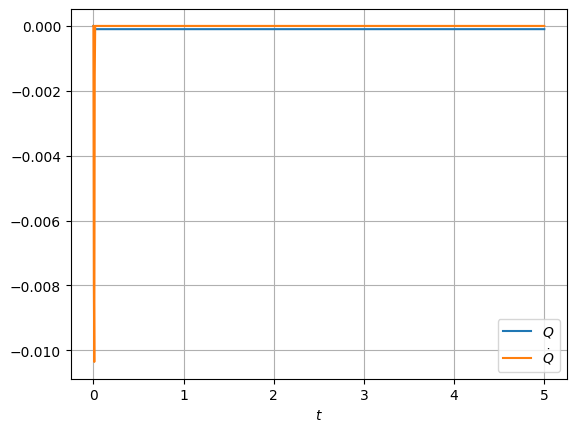

/home/david/enter/envs/fem-env/lib/python3.11/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])



elapsed time: 0.9 sec

=== Top 30 by CUMULATIVE time ===
         2531042 function calls (2530363 primitive calls) in 0.897 seconds

   Ordered by: cumulative time
   List reduced from 412 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        5    0.000    0.000    0.896    0.179 /home/david/enter/envs/fem-env/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3663(run_code)
        5    0.000    0.000    0.896    0.179 {built-in method builtins.exec}
        1    0.000    0.000    0.896    0.896 /tmp/ipykernel_130356/1732141556.py:1(<module>)
        1    0.000    0.000    0.896    0.896 /home/david/Documents/Solve_ivp_ns/solve_nivp/__init__.py:130(solve_nivp)
        1    0.001    0.001    0.896    0.896 /home/david/Documents/Solve_ivp_ns/solve_nivp/ODESolver.py:78(solve)
      186    0.000    0.000    0.893    0.005 /home/david/Documents/Solve_ivp_ns/solve_nivp/ODESystem.py:187(step)
      186    0.000    0.000    

In [27]:
import cProfile, pstats, io

tmax = 5.#*312500000000.0#5.
load_t_end = tmax  # set independently when you want to change the horizon only
n_steps_fixed = 10000
t_span = (0, tmax)
# t_eval = np.linspace(0, tmax, 31, endpoint=True)
t_eval = np.arange(0, tmax, D/L/vw/100)
# t_eval = np.append(t_eval, tmax)
h_fixed = tmax / n_steps_fixed

_h = [h_fixed]
gap_func_soc = lambda y, t: np.array([-1.0])
_, _, vtn_idx, vtt_idx, u1n_idx, u2t_idx, pt_idx = TPloc_idx["right"]
contact_tau_ratio = 1.00# set > 1.0 if you intentionally want immediate slip

def contact_offset_scale():
    # build_impulse_contact uses impulse-like reactions, so any
    # traction/stress reference must be multiplied by the current step size.
    return _h[0]

def contact_s0_impulse(y):
    return 0.99*s11_eff_0 * contact_offset_scale()

def contact_w0_impulse(y, k):
    return np.array([-s11_eff_0 * mu_fric(0.0, 0.0) * contact_tau_ratio * contact_offset_scale()])

def contact_s0_force(y):
    return 0.99 * s11_eff_0

def contact_w0_force(y, k):
    return np.array([-s11_eff_0 * mu_fric(0.0, 0.0) * contact_tau_ratio])

# Explicit local contact frame on the right boundary.
# Convention:
#   u_N is the right-boundary normal contact coordinate.
#   u_T > 0  : positive physical v2 at the right boundary.
# The continuum comparison is still between the cone normal reaction and
# -sigma_11 (compression is negative in the FEM stress field).
contact_vel_C = lil_matrix((2, ndofs_aug), dtype=float)
contact_vel_C[0, vtn_idx] = 1.0
contact_vel_C[1, vtt_idx] = 1.0
contact_vel_C = contact_vel_C.tocsr()

# Right-wall Signorini gap: g = -u1(right).
# Opening leftward gives g > 0; compression/contact gives g <= 0.
contact_gap_C = lil_matrix((2, ndofs_aug), dtype=float)
contact_gap_C[0, u1n_idx] = -1.0
contact_gap_C[1, u2t_idx] = 1.0
contact_gap_C = contact_gap_C.tocsr()

contact_B = contact_vel_C.T.tocsr()
contact_direct = dict(vel_normal_idx=vtn_idx, vel_tangential_idx=[vtt_idx], mu=mu_)
contact_blocks = [dict(vel_normal_idx=0, vel_tangential_idx=[1], mu=mu_)]
contact_vel_idx = np.array([vtn_idx, vtt_idx], dtype=int)
contact_other_idx = np.array(sorted(set(range(ndofs_aug)) - set(contact_vel_idx.tolist())), dtype=int)
contact_component_slices = [contact_vel_idx, contact_other_idx]

# slices = csr_matrix((2, ndofs), dtype=np.int32)
# slices[0, vtn_idx] = 1
# slices[1, vtt_idx] = 1

dx = (np.amax(mesh.p) - np.amin(mesh.p)) / mesh_elements
dt_crit = dx / vw
tau = 4 * dt_crit
print("smoother tau", tau)
q = lambda t: qv(t, t_start = 0, t_end = load_t_end, tau = tau).reshape(-1)
dq = lambda t: dqv(t, t_start = 0, t_end = load_t_end, tau = tau).reshape(-1)
# print(q(.2).squeeze())

smooth_amp = lambda t: smooth_pulse(t, t_start = 0, t_end = load_t_end, tau = tau)
force_left = lambda t: np.array([0,0,0,0]) * smooth_amp(t) * L**1
force_right = lambda t: np.array([0,0*1e3,0,0]) * smooth_amp(t) * L**1

ts = np.linspace(0, tmax, 1000, endpoint=True)
plt.plot(ts,q(ts).T, label = "$Q$")
plt.plot(ts,dq(ts).T, label = "$\\dot Q$")
plt.legend()
plt.xlabel("$t$")
plt.grid(True)
plt.show()

# atol_fields = np.array([1e-9,1e-12,1e-9,1e-10])
# atol = get_atol(atol_fields)
# rtol = 1e-8

def rhs_jac_aug(t, y):
    J = A_D_jac_template.copy()
    v2 = y[vtt_idx]
    J[slip_idx, vtt_idx] = v2 / np.sqrt(v2**2 + eps_slip)
    return J

# Workaround: the explicit C_extract path in build_impulse_contact
# currently assembles a Jacobian that stalls the SOC semismooth Newton
# solve, even though the RHS matches the direct-index path.  Build a
# direct-index companion solely to reuse its working rhs_jac.
cs_gbk_direct_jac = build_impulse_contact(
    A=E_D,
    rhs_smooth=rhs_plant,
    y0=y0,
    contacts=[contact_direct],
    gap_func=gap_func_soc,
    theta = 1.0,
    get_s0=contact_s0_impulse,
    get_w0=contact_w0_impulse,
    step_size_ref=_h,
    rhs_jac=rhs_jac_aug,
)

cs_gbk = build_impulse_contact(
    A=E_D,
    rhs_smooth=rhs_plant,
    y0=y0,
    contacts=contact_blocks,
    C_extract=contact_gap_C,
    D_extract=contact_vel_C,
    B=contact_B,
    component_slices=contact_component_slices,
    gap_func=gap_func_soc,
    theta = 1.0,
    # fremond_contact=True,
    get_s0=contact_s0_impulse,
    get_w0=contact_w0_impulse,
    step_size_ref=_h,
    rhs_jac=rhs_jac_aug,               # ← augmented Jacobian with slip derivative
)
cs_gbk.rhs_jac = cs_gbk_direct_jac.rhs_jac
cs_gbk.component_slices = cs_gbk_direct_jac.component_slices
if hasattr(cs_gbk.projection, '_velocity_dof_map'):
    cs_gbk.projection._velocity_dof_map = [contact_vel_idx.copy()]

import sys
profiling_enabled = sys.getprofile() is None
profiler = cProfile.Profile() if profiling_enabled else None
if profiler is not None:
    profiler.enable()

start = time.time()

t_gbk, y_gbk, h_gbk_hist, fk_gbk, info_gbk = solve_nivp.solve_ivp_ns(
    fun=cs_gbk.rhs,
    t_span=t_span,
    y0=cs_gbk.y0,
    A=cs_gbk.A,
    method='backward_euler',   # ← implicit Euler (first-order, A-stable)
    projection=cs_gbk.projection,
    solver='semismooth_newton',
    solver_opts=dict(
        tol=1e-6,
        max_iter=100,
        rhs_jac=cs_gbk.rhs_jac,
        linear_solver='splu',           # ← direct sparse LU (SuperLU)
    ),
    component_slices=cs_gbk.component_slices,
    integrator_opts=cs_gbk.integrator_opts,
    adaptive=False,
    h0=h_fixed,
    dae_var_weight='auto',     # auto-excludes algebraic DOFs from error norm
    
)
   
end = time.time(); time_sol = end - start

if profiler is not None:
    profiler.disable()

print("\nelapsed time:", round(time_sol if time_sol < 60 else time_sol / 60, 2), 'sec' if time_sol < 60 else 'min')

if profiler is not None:
    # ── Top 30 by cumulative time ──
    stream = io.StringIO()
    ps = pstats.Stats(profiler, stream=stream)
    ps.sort_stats('cumulative')
    ps.print_stats(30)
    print("\n=== Top 30 by CUMULATIVE time ===")
    print(stream.getvalue())

    # ── Top 30 by total (self) time ──
    stream2 = io.StringIO()
    ps2 = pstats.Stats(profiler, stream=stream2)
    ps2.sort_stats('tottime')
    ps2.print_stats(30)
    print("\n=== Top 30 by TOTAL (self) time ===")
    print(stream2.getvalue())
else:
    print("Profiler skipped because another profile function is already active.")

# Extract physics DOFs (strip slip + reactions) and slip history
n_phys = cs_gbk.n_phys          # ndofs + 1 (includes slip)
ts = t_gbk
zs = y_gbk.T[:ndofs, :]         # original physics DOFs only
slip_hist = y_gbk.T[slip_idx, :]  # accumulated slip over time

def summarize_backend(name, t_hist, info_hist):
    t_end = float(t_hist[-1]) if len(t_hist) else np.nan
    reached_final = bool(len(t_hist)) and (t_end >= tmax - 0.5 * h_fixed)
    last_info = info_hist[-1] if info_hist else None
    print(f"{name} status: n_t={len(t_hist)}, t_end={t_end:.6g}, reached_final={reached_final}, last_info={last_info}")
    return reached_final

soc_reached_final = summarize_backend("SOC", t_gbk, info_gbk)

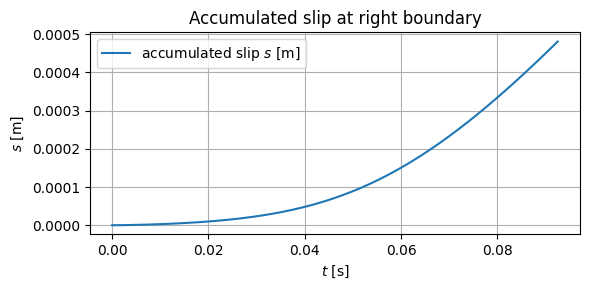

In [28]:
zs_split = split_sol(zs).transpose(2, 0, 1)
zs_split[:,:6,:]*=L
zs_split[:,6,:]/=L
# print( zs_split.argmax(axis=(1,2)))
vmin=np.amin(zs_split, axis=(0,2))*1.1
vmax=np.amax(zs_split, axis=(0,2))*1.1
# print(vmin)
# print(vmax)
# print(zs_split.shape)
ss_eff, es = compute_stress_strain(zs)
ss_eff/= L
I = np.eye(dim)
ss = ss_eff - α * zs_split[:, 6, None, None, :] * I[None, :, :, None]
vmin_ss_eff=np.amin(ss_eff, axis=(0,3))*1.1
vmax_ss_eff=np.amax(ss_eff, axis=(0,3))*1.1
vmin_ss=np.amin(ss, axis=(0,3))*1.1
vmax_ss=np.amax(ss, axis=(0,3))*1.1
vmin_es=np.amin(es, axis=(0,3))*1.1
vmax_es=np.amax(es, axis=(0,3))*1.1

# Plot accumulated slip history
plt.figure(figsize=(6, 3))
plt.plot(ts, slip_hist * L, label="accumulated slip $s$ [m]")
plt.xlabel("$t$ [s]")
plt.ylabel("$s$ [m]")
plt.title("Accumulated slip at right boundary")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Results

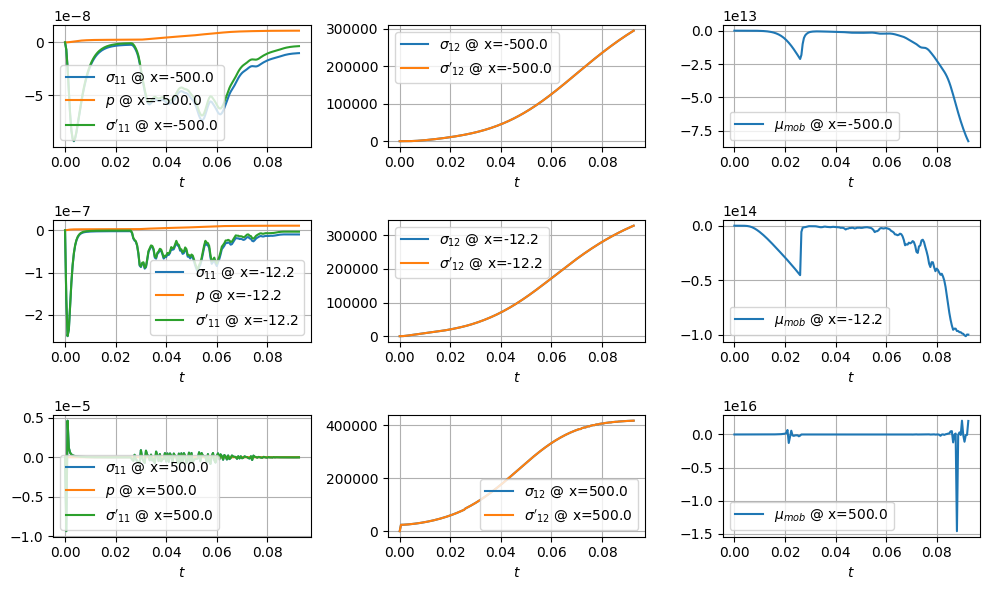

In [29]:
pids=[0, mesh_elements//2, -1]
plot_point_hist(ss, ss_eff, zs_split, pids)

In [30]:
@widgets.interact(tid=(0,len(ts)-1,1))
def show_animate(tid=len(ts)):
    plot_solution(zs_split[tid], vmin, vmax)
    print("@ t=",ts[tid])

interactive(children=(IntSlider(value=185, description='tid', max=185), Output()), _dom_classes=('widget-inter…

In [31]:
@widgets.interact(tid=(0,len(ts)-1,1))
def show_animate(tid=len(ts)):
    plot_tensor(ss_eff[tid], vmin_ss_eff, vmax_ss_eff, name="\\sigma'")
    plot_tensor(ss[tid], vmin_ss, vmax_ss, name="\\sigma")
    plt.show()

interactive(children=(IntSlider(value=185, description='tid', max=185), Output()), _dom_classes=('widget-inter…

In [32]:
@widgets.interact(tid=(0,len(ts)-1,1))
def show_animate(tid=len(ts)):
    plot_tensor(es[tid], vmin_es, vmax_es, name="\\epsilon")

interactive(children=(IntSlider(value=185, description='tid', max=185), Output()), _dom_classes=('widget-inter…

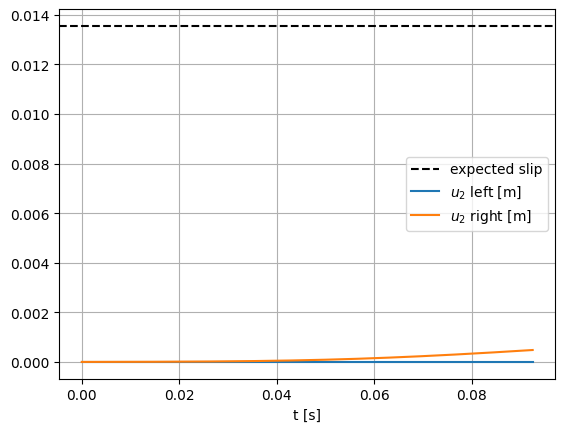

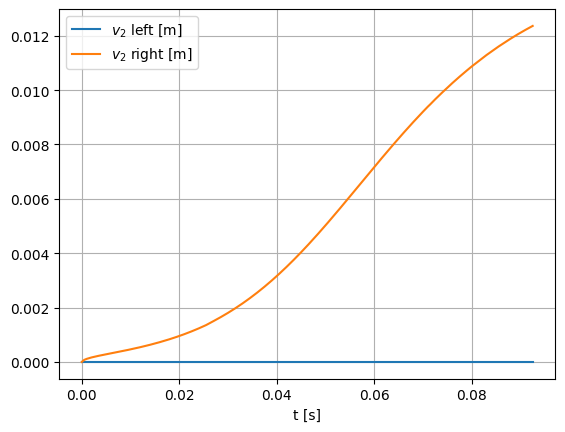

In [33]:
tst=0
dof_id = 5
plt.axhline(expd_slip*L, color='black', linestyle='--',label="expected slip")
plt.plot(ts[tst:],zs_split[tst:,dof_id,0],label="$u_2$ left [m]")
plt.plot(ts[tst:],zs_split[tst:,dof_id,-1],label="$u_2$ right [m]")
plt.grid(True)
plt.xlabel("t [s]")
plt.legend()
plt.show()
dof_id = 1
plt.plot(ts[tst:],zs_split[tst:,dof_id,0],label="$v_2$ left [m]")
plt.plot(ts[tst:],zs_split[tst:,dof_id,-1],label="$v_2$ right [m]")
plt.grid(True)
plt.xlabel("t [s]")
plt.legend()
plt.show()

## NCP & Alart-Curnier comparison

In [34]:
# ── NCP contact backend (Fischer-Burmeister, force reactions) ──
# Prestress enters through the cone shift (get_s0 / get_w0), mirroring the
# SOC/impulse backend: s0 = 0.99*sigma_11 (slightly shrunk normal ray), and
# w0 = -sigma_11 * mu(0). |w0|/s0 = mu(0)/0.99 > mu(0) places the initial
# contact state just outside the scaled Coulomb cone, so the NCP solve must
# produce a nonzero reaction at t=0 to remain feasible.
from solve_nivp.ncp_contact import build_ncp_contact

def contact_s0_force_vec(y):
    # Shrink normal ray by 0.99 so the static state sits strictly
    # inside the open cone; matches the 0.99 factor in expd_slip.
    return np.array([0.99 * s11_eff_0])

def contact_w0_force_vec(y, k):
    # Scale tangential by the same 0.99 factor and nudge just above
    # the cone boundary (1.001) to guarantee slip nucleation.
    return np.array([-0.99 * s11_eff_0 * mu_fric(0.0, 0.0) * 1.001])

cs_ncp = build_ncp_contact(
    A=E_D,
    rhs_smooth=rhs_plant,
    y0=y0,
    contacts=contact_blocks,
    C_extract=contact_gap_C,
    D_extract=contact_vel_C,
    B=contact_B,
    component_slices=contact_component_slices,
    gap_func=None,
    theta=1.0,
    reaction_units='force',
    get_s0=contact_s0_force_vec,
    get_w0=contact_w0_force_vec,
    rhs_jac=rhs_jac_aug,
    ncp_type='fischer_burmeister',
    normal_r='auto',
    friction_r='auto',
    inactive_handling='ncp',
)

# Per-DOF nonlinear tolerances: drive rtol to zero on the reaction rows
# so the WRMS norm doesn't dilute their residual (project_desaxce_fix).
n_aug = cs_ncp.y0.size
nl_atol_ncp = np.full(n_aug, 1e-8)
nl_rtol_ncp = np.full(n_aug, 1e-6)
nl_atol_ncp[ndofs_aug:] = 1e-10
nl_rtol_ncp[ndofs_aug:] = 0.0

# Slip-weakening has smooth, slowly-varying reactions, so warm-starting
# from the previous step's r (disabling cold_start_slices) and full Newton
# steps (damped_step_fraction=1.0) drop the iteration count from 100+/step
# to ~13/step at steady state. Macklin cold-start stays as the library
# default for impact problems.
solver_opts_ncp = dict(cs_ncp.solver_opts)
solver_opts_ncp.pop('cold_start_slices', None)     # warm-start r across steps
solver_opts_ncp['damped_step_fraction'] = 1.0
solver_opts_ncp['diagonal_regularization'] = 0.0
solver_opts_ncp.update(
    tol=1e-6,
    max_iter=500,
    rhs_jac=cs_ncp.rhs_jac,
    linear_solver='splu',
)

start = time.time()
t_ncp, y_ncp, h_ncp_hist, fk_ncp, info_ncp = solve_nivp.solve_ivp_ns(
    fun=cs_ncp.rhs,
    t_span=t_span,
    y0=cs_ncp.y0,
    A=cs_ncp.A,
    method='backward_euler',
    projection=cs_ncp.projection,
    solver='semismooth_newton',
    solver_opts=solver_opts_ncp,
    nl_atol=nl_atol_ncp,
    nl_rtol=nl_rtol_ncp,
    component_slices=cs_ncp.component_slices,
    integrator_opts=cs_ncp.integrator_opts,
    adaptive=False,
    h0=h_fixed,
    dae_var_weight='auto',
    active_set_filter=True,
)
time_ncp = time.time() - start
print(f"NCP elapsed: {time_ncp:.2f} s")

zs_ncp = y_ncp.T[:ndofs, :]
slip_ncp = y_ncp.T[slip_idx, :]
ncp_reached_final = summarize_backend("NCP", t_ncp, info_ncp)
print(f"NCP final slip  = {slip_ncp[-1] * L:.6e} m")
if EQslip:
    print(f"Analytic slip   = {expd_slip * L:.6e} m")
    print(f"Relative error  = {abs(slip_ncp[-1] - expd_slip) / abs(expd_slip):.3%}")


NCP elapsed: 0.74 s
NCP status: n_t=220, t_end=0.1095, reached_final=False, last_info=(1.1507497447676907, False, 500)
NCP final slip  = 2.663121e-04 m
Analytic slip   = 1.355357e-02 m
Relative error  = 98.035%


In [35]:
# ── NCP sanity: refinement + prestress invariance ──
# (1) Halving dt must produce a converging final slip.
# (2) Scaling s11_eff_0 must scale the final slip linearly when EQslip holds.

def run_ncp(n_steps, s11_scale=1.0):
    s11_ref = s11_eff_0 * s11_scale

    def gs0(y):
        return np.array([0.99 * s11_ref])

    def gw0(y, k):
        return np.array([-0.99 * s11_ref * mu_fric(0.0, 0.0) * 1.001])

    cs = build_ncp_contact(
        A=E_D, rhs_smooth=rhs_plant, y0=y0,
        contacts=contact_blocks,
        C_extract=contact_gap_C, D_extract=contact_vel_C,
        B=contact_B, component_slices=contact_component_slices,
        gap_func=None, theta=1.0, reaction_units='force',
        get_s0=gs0, get_w0=gw0, rhs_jac=rhs_jac_aug,
        ncp_type='fischer_burmeister',
        normal_r='auto', friction_r='auto', inactive_handling='ncp',
    )
    n_aug = cs.y0.size
    at = np.full(n_aug, 1e-8); rt = np.full(n_aug, 1e-6)
    at[ndofs_aug:] = 1e-10; rt[ndofs_aug:] = 0.0
    sopts = dict(cs.solver_opts)
    sopts.pop('cold_start_slices', None)
    sopts['damped_step_fraction'] = 1.0
    sopts['diagonal_regularization'] = 0.0
    sopts.update(tol=1e-6, max_iter=500, rhs_jac=cs.rhs_jac,
                 linear_solver='splu')
    h = tmax / n_steps
    t_, y_, *_ = solve_nivp.solve_ivp_ns(
        fun=cs.rhs, t_span=t_span, y0=cs.y0, A=cs.A,
        method='backward_euler', projection=cs.projection,
        solver='semismooth_newton', solver_opts=sopts,
        nl_atol=at, nl_rtol=rt,
        component_slices=cs.component_slices,
        integrator_opts=cs.integrator_opts,
        adaptive=False, h0=h, dae_var_weight='auto',
        active_set_filter=True,
    )
    return t_, y_[:, slip_idx]

print("--- Step refinement (s11_eff_0 fixed) ---")
for n in (2500, 5000, 10000, 20000):
    t_, s_ = run_ncp(n)
    print(f"  n={n:>5d}  slip(tmax)={s_[-1] * L:.6e} m")
if EQslip:
    print(f"  analytic          ={expd_slip * L:.6e} m")

print("--- Prestress sweep (n=10000) ---")
for scale in (0.5, 1.0, 2.0):
    _, s_ = run_ncp(10000, s11_scale=scale)
    print(f"  s11_scale={scale}  slip(tmax)={s_[-1] * L:.6e} m  "
          f"(expected =/= {scale * (expd_slip * L if EQslip else 1):.6e})")


--- Step refinement (s11_eff_0 fixed) ---
  n= 2500  slip(tmax)=1.358513e-02 m
  n= 5000  slip(tmax)=5.300368e-03 m
  n=10000  slip(tmax)=2.663121e-04 m
  n=20000  slip(tmax)=8.142493e-05 m
  analytic          =1.355357e-02 m
--- Prestress sweep (n=10000) ---
  s11_scale=0.5  slip(tmax)=2.164056e-04 m  (expected =/= 6.776786e-03)
  s11_scale=1.0  slip(tmax)=2.663121e-04 m  (expected =/= 1.355357e-02)
  s11_scale=2.0  slip(tmax)=3.415223e-04 m  (expected =/= 2.710714e-02)


In [36]:
# ── Direct NCP Jacobian diagnostic ──
# Test the Jacobian by finite-difference check on the augmented RHS

y0_ncp = cs_ncp.y0.copy()
n_phys_ncp = cs_ncp.n_phys
n_react_ncp = y0_ncp.shape[0] - n_phys_ncp

# Evaluate J analytically
J_an = cs_ncp.rhs_jac(h_fixed, y0_ncp, y0_ncp, None, h_fixed)
if hasattr(J_an, 'toarray'):
    J_an = J_an.toarray()

# Verify by finite differences
eps = 1e-7
f0 = cs_ncp.rhs(h_fixed, y0_ncp, y0_ncp, None, h_fixed)
J_fd = np.zeros_like(J_an)
for j in [u1n_idx, vtn_idx, vtt_idx, slip_idx, n_phys_ncp, n_phys_ncp+1]:
    yp = y0_ncp.copy()
    yp[j] += eps
    fp = cs_ncp.rhs(h_fixed, yp, y0_ncp, None, h_fixed)
    J_fd[:, j] = (fp - f0) / eps

# Show r0 row comparison for key columns
key_cols = [u1n_idx, vtn_idx, vtt_idx, slip_idx, n_phys_ncp, n_phys_ncp+1]
col_names = ['u_N', 'v_N', 'v_T', 'slip', 'r0', 'r1']
print("Contact Jacobian rows (analytical vs FD):")
for i in range(n_react_ncp):
    row_idx = n_phys_ncp + i
    an_vals = [f"{J_an[row_idx, c]:.6e}" for c in key_cols]
    fd_vals = [f"{J_fd[row_idx, c]:.6e}" for c in key_cols]
    print(f"  r{i} analytical: [{', '.join(an_vals)}]")
    print(f"  r{i} FD:         [{', '.join(fd_vals)}]")
    # Check any non-zero analytical entries
    row_an = J_an[row_idx, :]
    nz = np.nonzero(np.abs(row_an) > 1e-15)[0]
    if len(nz) == 0:
        print(f"  r{i} ** analytical row ALL ZEROS, checking FD for nonzeros **")
        nz_fd = np.nonzero(np.abs(J_fd[row_idx, :]) > 1e-10)[0]
        if len(nz_fd) > 0:
            print(f"  r{i} FD nonzeros at cols: {list(nz_fd)}")
            print(f"  r{i} FD values: {[J_fd[row_idx, j] for j in nz_fd]}")
    print()

# Also check: what does the RHS at initial state look like?
print(f"f0[react] = {f0[n_phys_ncp:]}")
print(f"f0[u_N]   = {f0[u1n_idx]:.6e}")
print(f"f0[v_N]   = {f0[vtn_idx]:.6e}")
print(f"f0[v_T]   = {f0[vtt_idx]:.6e}")


Contact Jacobian rows (analytical vs FD):
  r0 analytical: [1.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00]
  r0 FD:         [9.999999e-01, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00]

  r1 analytical: [0.000000e+00, 0.000000e+00, -1.002006e+00, 0.000000e+00, -9.261974e+04, -1.543659e+05]
  r1 FD:         [0.000000e+00, 0.000000e+00, -1.002007e+00, 6.112905e+02, -9.261973e+04, -1.543659e+05]

f0[react] = [ -0.         366.04135135]
f0[u_N]   = 0.000000e+00
f0[v_N]   = 0.000000e+00
f0[v_T]   = 0.000000e+00


In [37]:
# ── Quick check: does WRMS parameter reach the solver? ──
from solve_nivp.nonlinear_solvers import ImplicitEquationSolver
if 'cs_ac' not in globals():
    print("Run the Alart-Curnier backend cell before this diagnostic.")
else:
    solver_test = ImplicitEquationSolver(
        method='semismooth_newton',
        proj=cs_ac.projection,
        nl_atol=1e-6,
        nl_rtol=1e-6,
        tol=1e-6,
        max_iter=100,
        linear_solver='splu',
    )
    print(f"_use_weighted_norm = {solver_test._use_weighted_norm}")
    print(f"_nl_atol_raw = {solver_test._nl_atol_raw}")
    print(f"_nl_rtol_raw = {solver_test._nl_rtol_raw}")
    print(f"tol = {solver_test.tol}")

Run the Alart-Curnier backend cell before this diagnostic.


In [38]:
# ── Alart-Curnier contact backend ──
from solve_nivp.alart_curnier_contact import build_alart_curnier_contact

cs_ac = build_alart_curnier_contact(
    A=E_D,
    rhs_smooth=rhs_plant,
    y0=y0,
    contacts=contact_blocks,
    C_extract=contact_gap_C,
    D_extract=contact_vel_C,
    B=contact_B,
    component_slices=contact_component_slices,
    gap_func=None,
    theta=1.0,
    reaction_units='force',
    get_s0=contact_s0_force,
    get_w0=contact_w0_force,
    rhs_jac=rhs_jac_aug,
    rho_n=1.0,  # match BE diagonal at v_N ≈ 1.0
    rho_t=1.0,  # match physical scale
)

start = time.time()
t_ac, y_ac, h_ac_hist, fk_ac, info_ac = solve_nivp.solve_ivp_ns(
    fun=cs_ac.rhs,
    t_span=t_span,
    y0=cs_ac.y0,
    A=cs_ac.A,
    method='backward_euler',
    projection=cs_ac.projection,
    solver='semismooth_newton',
    solver_opts=dict(
        tol=1e-6,
        max_iter=100,
        rhs_jac=cs_ac.rhs_jac,
        linear_solver='splu',
    ),
    component_slices=cs_ac.component_slices,
    integrator_opts=cs_ac.integrator_opts,
    adaptive=False,
    h0=h_fixed,
    dae_var_weight='auto',
)
time_ac = time.time() - start
print(f"AC elapsed: {time_ac:.2f} s")

zs_ac = y_ac.T[:ndofs, :]
slip_ac = y_ac.T[slip_idx, :]
ac_reached_final = summarize_backend("Alart-Curnier", t_ac, info_ac)

AC elapsed: 0.09 s
Alart-Curnier status: n_t=7, t_end=0.003, reached_final=False, last_info=(1.5109360026192928e-06, False, 100)


In [39]:
# Diagnostic: what does the AC residual/Jacobian look like at t=0?
import numpy as np

# Build AC system fresh with extra diagnostics
y_test = cs_ac.y0.copy()
n_p = cs_ac.n_phys

# Evaluate rhs and jac at t=0 with prev_state=y_test, h=h_fixed
rhs_val = cs_ac.rhs(0, y_test, y_test, None, h_fixed)
jac_val = cs_ac.rhs_jac(0, y_test, y_test, None, h_fixed)

# BE residual: E*(y-y0)/h - theta*f(t1,y) - (1-theta)*f(t0,y0) 
# With theta=1 and y=y0: E*0/h - f(0,y0) = -f(0,y0)
# So rhs = f(0,y0) and BE residual = -rhs
# The actual residual vector:
A_ac = np.asarray(cs_ac.A.todense()) if hasattr(cs_ac.A, 'todense') else np.asarray(cs_ac.A)
BE_res_ac = A_ac @ np.zeros_like(y_test) - h_fixed * rhs_val

print(f"AC y0 shape: {y_test.shape}")
print(f"AC n_phys: {n_p}")
print(f"AC rhs norm: {np.linalg.norm(rhs_val):.6e}")
print(f"AC rhs at reaction DOFs: {rhs_val[n_p:]}")
print(f"AC y0 at reaction DOFs: {y_test[n_p:]}")
print()

# Check the Jacobian conditioning
J_ac = np.asarray(jac_val.todense()) if hasattr(jac_val, 'todense') else np.asarray(jac_val)

# Look at the reaction DOF rows of the Jacobian
n_r = len(y_test) - n_p
print(f"Reaction DOFs: {n_r}")
for i in range(n_r):
    row = J_ac[n_p + i, :]
    nz = np.flatnonzero(np.abs(row) > 1e-15)
    print(f"  r_{i} row: nnz={len(nz)}, nonzero cols={nz}, vals={row[nz]}")

# Full BE Jacobian 
BE_jac_ac = A_ac / h_fixed - J_ac
cond_ac = np.linalg.cond(BE_jac_ac)
print(f"\nBE Jacobian cond: {cond_ac:.3e}")

# Check if there's a zero or near-zero row
row_norms = np.linalg.norm(BE_jac_ac, axis=1)
min_row_norm = np.min(row_norms)
min_row_idx = np.argmin(row_norms)
print(f"Min row norm: {min_row_norm:.6e} at row {min_row_idx}")
print(f"Reaction DOF rows norms: {row_norms[n_p:]}")


AC y0 shape: (543,)
AC n_phys: 541
AC rhs norm: 2.400000e-02
AC rhs at reaction DOFs: [ 0.    -0.024]
AC y0 at reaction DOFs: [0. 0.]

Reaction DOFs: 2
  r_0 row: nnz=1, nonzero cols=[287], vals=[1.]
  r_1 row: nnz=2, nonzero cols=[541 542], vals=[0.6 1. ]



BE Jacobian cond: 1.086e+15
Min row norm: 9.708996e-03 at row 50
Reaction DOF rows norms: [1.         1.16619038]


In [40]:
# Diagnose split_sol shapes
(v, vb), (r, rb), (u, ub), (p, pb) = basis.split(zs)
v_list = [vi[vib.nodal_dofs[0]] for vi, vib in vb.split(v)]
r_list = [ri[rib.nodal_dofs[0]] for ri, rib in rb.split(r)]
u_list = [ui[uib.nodal_dofs[0]] for ui, uib in rb.split(u)]
print(f"v shapes: {[x.shape for x in v_list[:dim]]}")
print(f"r shapes: {[x.shape for x in r_list[:dim]]}")
print(f"u shapes: {[x.shape for x in u_list[:dim]]}")
print(f"p.shape before indexing: {p.shape}")
print(f"pb.nodal_dofs shape: {pb.nodal_dofs.shape}, len: {len(pb.nodal_dofs)}")
if len(pb.nodal_dofs) == 0:
    print("P0 branch")
else:
    p_indexed = p[pb.nodal_dofs].squeeze()
    print(f"p after indexing+squeeze: {p_indexed.shape}")
print(f"xcoords.shape: {xcoords.shape}")
print(f"mesh_elements: {mesh_elements}")

v shapes: [(42, 186), (42, 186)]
r shapes: [(42, 186), (42, 186)]
u shapes: [(42, 186), (42, 186)]
p.shape before indexing: (42, 186)
pb.nodal_dofs shape: (1, 42), len: 1
p after indexing+squeeze: (42, 186)
xcoords.shape: (42,)
mesh_elements: 41


In [41]:
# ── Convergence diagnostics (compact) ──
for name, t_h, info_h, y_h, cs_h, zs_h, slip_h in [
    ("SOC",  t_gbk, info_gbk, y_gbk, cs_gbk, zs, slip_hist),
    ("NCP",  t_ncp, info_ncp, y_ncp, cs_ncp, zs_ncp, slip_ncp),
    ("AC",   t_ac,  info_ac,  y_ac,  cs_ac,  zs_ac,  slip_ac),
]:
    nt = len(t_h)
    t_end = float(t_h[-1]) if nt else 0
    n_fail = sum(1 for _, c, _ in info_h if not c)
    last3 = info_h[-3:] if info_h else []
    r_final = y_h[-1, cs_h.n_phys:] if nt else None
    slip_f = float(slip_h[-1]) if nt else 0
    v2_f = float(zs_h[vtt_idx, -1]) * L if nt else 0
    print(f"--- {name} ---")
    print(f"  steps={nt}, t_end={t_end:.4g}/{tmax}, failed={n_fail}/{len(info_h)}")
    print(f"  last info: {last3}")
    if EQslip:
        print(f"  slip={slip_f:.4e}, expected={expd_slip:.4e}, ratio={slip_f/expd_slip:.4f}")
    else:
        print(f"  slip={slip_f:.4e}")
    print(f"  v2_end={v2_f:.4e} m/s, reactions={r_final}")
    print()

--- SOC ---
  steps=186, t_end=0.0925/5.0, failed=1/186
  last info: [(12314.52856197234, True, 3), (12362.193289610173, True, 2), (1.4405009204891674e-06, False, 100)]
  slip=4.8059e+02, expected=1.3554e+04, ratio=0.0355
  v2_end=1.2362e-02 m/s, reactions=[4.13584468e-08 2.08359312e-04]

--- NCP ---
  steps=220, t_end=0.1095/5.0, failed=1/220
  last info: [(0.0003509521484375, True, 9), (0.00042724609375, True, 9), (1.1507497447676907, False, 500)]
  slip=2.6631e+02, expected=1.3554e+04, ratio=0.0196
  v2_end=9.3616e-03 m/s, reactions=[0.         0.37076281]

--- AC ---
  steps=7, t_end=0.003/5.0, failed=1/7
  last info: [(4.76837158203125e-07, True, 10), (4.76837158203125e-07, True, 34), (1.5109360026192928e-06, False, 100)]
  slip=4.4654e-01, expected=1.3554e+04, ratio=0.0000
  v2_end=2.0978e-04 m/s, reactions=[0.         0.02576435]



In [42]:
# ── Physical scale check ──
print(f"L = {L}")
print(f"D = {D} [dim-less],  D*L = {D*L} [m]")
print(f"G = {G} [dim-less],  G/L = {G/L:.4e} [Pa]")
print(f"s11_eff_0 = {s11_eff_0} [dim-less],  s11_eff_0/L = {s11_eff_0/L:.4e} [Pa]")
print(f"mu_res = {mu_res},  Dmu = {Dmu},  Dc = {Dc} [dim-less], Dc*L = {Dc*L:.4e} [m]")
print(f"vw = {vw} [dim-less],  vw*L = {vw*L:.4e} [m/s]")
print(f"h_fixed = {h_fixed:.4e}")
print(f"dt_crit / h_fixed = {dt_crit / h_fixed:.4e}")
print(f"Expected slip = {expd_slip:.4e} [dim-less] = {expd_slip*L:.4e} [m]")
print()

# Check: is s11_eff_0 actually compressive? What's the initial stress state?
print("Initial state: y0 at contact node")
print(f"  y0[vtn_idx={vtn_idx}] = {y0[vtn_idx]:.4e}  (normal vel)")
print(f"  y0[vtt_idx={vtt_idx}] = {y0[vtt_idx]:.4e}  (tangential vel)")
print(f"  y0[slip_idx={slip_idx}] = {y0[slip_idx]:.4e}")
print()

# Check what A_D @ y0 gives at contact DOFs
rhs0 = A_D @ y0
print(f"A_D @ y0 at vtn_idx: {rhs0[vtn_idx]:.4e}")
print(f"A_D @ y0 at vtt_idx: {rhs0[vtt_idx]:.4e}")
print()

# The load function q(t)
print(f"q(0) = {q(0.)}")
print(f"q(h_fixed) = {q(h_fixed)}")
print(f"q(tmax/2) = {q(tmax/2.)}")
print(f"q(tmax) = {q(tmax)}")
print()

# Check the driving force: what pushes slip?
# rhs_plant at t=0, y=y0
rhs_at_0 = rhs_plant(0., y0)
print(f"rhs_plant(0, y0) at vtn_idx: {rhs_at_0[vtn_idx]:.6e}")
print(f"rhs_plant(0, y0) at vtt_idx: {rhs_at_0[vtt_idx]:.6e}")
print(f"rhs_plant(0, y0) at slip_idx: {rhs_at_0[slip_idx]:.6e}")
print()

# Is rhs_smooth (A_D @ y) = 0 at t=0 because y0 = 0? Then what drives slip?
# The friction contact should be providing the tangential force...
# but the prestress s0 is the only thing that activates friction.
# Let's check: in SOC, does the projection even activate?
print(f"Friction coefficient from mu_(y0): {mu_(y0)}")
print(f"mu_fric(0, 0) = {mu_fric(0., 0.)}")
print(f"Stress drop: Dmu * s11_eff_0 = {Dmu * s11_eff_0:.4e}")
print(f"Stiffness:   G / (D/L) = {G / (D/L):.4e}")
print(f"Ratio (|drop|/stiffness): {abs(Dmu * s11_eff_0) / (G / (D/L)):.4e}")

L = 1e-06
D = 1000.0 [dim-less],  D*L = 0.001 [m]
G = 29217.391304347828 [dim-less],  G/L = 2.9217e+10 [Pa]
s11_eff_0 = 4.0 [dim-less],  s11_eff_0/L = 4.0000e+06 [Pa]
mu_res = 0.5,  Dmu = -0.1,  Dc = 100.00000000000001 [dim-less], Dc*L = 1.0000e-04 [m]
vw = 5827445886.863149 [dim-less],  vw*L = 5.8274e+03 [m/s]
h_fixed = 5.0000e-04
dt_crit / h_fixed = 8.3708e+00
Expected slip = 1.3554e+04 [dim-less] = 1.3554e-02 [m]

Initial state: y0 at contact node
  y0[vtn_idx=287] = 0.0000e+00  (normal vel)
  y0[vtt_idx=288] = 0.0000e+00  (tangential vel)
  y0[slip_idx=540] = 0.0000e+00

A_D @ y0 at vtn_idx: 0.0000e+00
A_D @ y0 at vtt_idx: 0.0000e+00

q(0) = [-0.]
q(h_fixed) = [-2.54597781e-08]
q(tmax/2) = [-0.0001]
q(tmax) = [-0.0001]

rhs_plant(0, y0) at vtn_idx: 0.000000e+00
rhs_plant(0, y0) at vtt_idx: 0.000000e+00
rhs_plant(0, y0) at slip_idx: 0.000000e+00

Friction coefficient from mu_(y0): 0.6
mu_fric(0, 0) = 0.6
Stress drop: Dmu * s11_eff_0 = -4.0000e-01
Stiffness:   G / (D/L) = 2.9217e-05


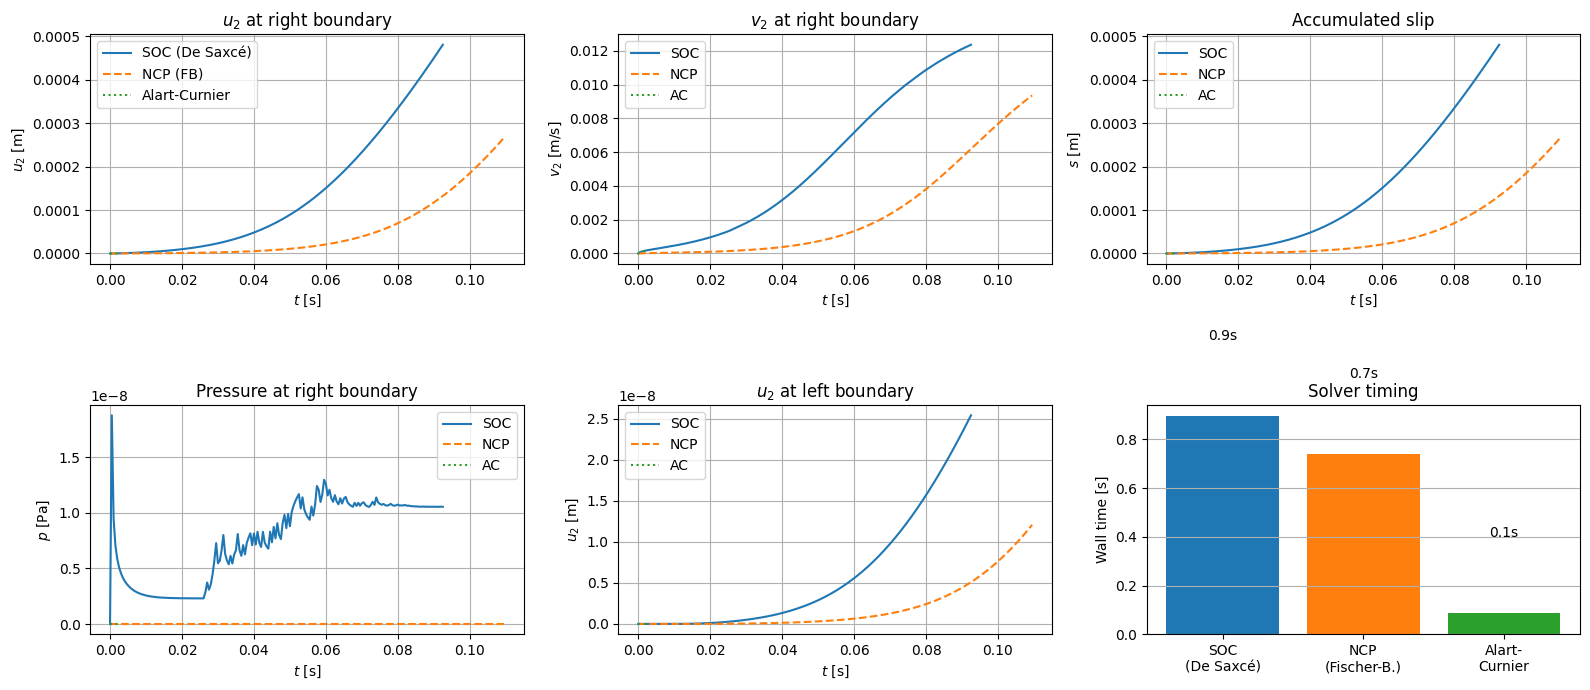

Relative L2 difference in u2(right) vs SOC on the common time interval:
  NCP (FB):          7.852217e-01  over [0, 0.0925] s (100.0% of SOC horizon)
  Alart-Curnier:     7.536179e-03  over [0, 0.0030] s (3.2% of SOC horizon)

Wall times:  SOC=0.90s  |  NCP=0.74s  |  AC=0.09s


In [43]:
# ── Comparison: SOC vs NCP vs Alart-Curnier ──
# Extract boundary DOF indices directly (avoids split_sol shape issues)
_, _, _, _, _, u2_idx_right, p_idx_right = TPloc_idx["right"]
_, _, _, _, _, u2_idx_left, _ = TPloc_idx["left"]

fig, axes = plt.subplots(2, 3, figsize=(16, 7))

# u2 at right boundary
ax = axes[0, 0]
ax.plot(ts, zs[u2_idx_right, :] * L, label="SOC (De Saxcé)")
ax.plot(t_ncp, zs_ncp[u2_idx_right, :] * L, '--', label="NCP (FB)")
ax.plot(t_ac, zs_ac[u2_idx_right, :] * L, ':', label="Alart-Curnier")
ax.set_xlabel("$t$ [s]"); ax.set_ylabel("$u_2$ [m]")
ax.set_title("$u_2$ at right boundary")
ax.legend(); ax.grid(True)

# v2 at right boundary
ax = axes[0, 1]
ax.plot(ts, zs[vtt_idx, :] * L, label="SOC")
ax.plot(t_ncp, zs_ncp[vtt_idx, :] * L, '--', label="NCP")
ax.plot(t_ac, zs_ac[vtt_idx, :] * L, ':', label="AC")
ax.set_xlabel("$t$ [s]"); ax.set_ylabel("$v_2$ [m/s]")
ax.set_title("$v_2$ at right boundary")
ax.legend(); ax.grid(True)

# Accumulated slip
ax = axes[0, 2]
ax.plot(ts, slip_hist * L, label="SOC")
ax.plot(t_ncp, slip_ncp * L, '--', label="NCP")
ax.plot(t_ac, slip_ac * L, ':', label="AC")
ax.set_xlabel("$t$ [s]"); ax.set_ylabel("$s$ [m]")
ax.set_title("Accumulated slip")
ax.legend(); ax.grid(True)

# Pressure at right boundary
ax = axes[1, 0]
ax.plot(ts, zs[p_idx_right, :] / L, label="SOC")
ax.plot(t_ncp, zs_ncp[p_idx_right, :] / L, '--', label="NCP")
ax.plot(t_ac, zs_ac[p_idx_right, :] / L, ':', label="AC")
ax.set_xlabel("$t$ [s]"); ax.set_ylabel("$p$ [Pa]")
ax.set_title("Pressure at right boundary")
ax.legend(); ax.grid(True)

# u2 at left boundary
ax = axes[1, 1]
ax.plot(ts, zs[u2_idx_left, :] * L, label="SOC")
ax.plot(t_ncp, zs_ncp[u2_idx_left, :] * L, '--', label="NCP")
ax.plot(t_ac, zs_ac[u2_idx_left, :] * L, ':', label="AC")
ax.set_xlabel("$t$ [s]"); ax.set_ylabel("$u_2$ [m]")
ax.set_title("$u_2$ at left boundary")
ax.legend(); ax.grid(True)

# Timing comparison
ax = axes[1, 2]
labels = ["SOC\n(De Saxcé)", "NCP\n(Fischer-B.)", "Alart-\nCurnier"]
times = [time_sol, time_ncp, time_ac]
bars = ax.bar(labels, times, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
for b, t_ in zip(bars, times):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
            f"{t_:.1f}s", ha='center', va='bottom', fontsize=10)
ax.set_ylabel("Wall time [s]")
ax.set_title("Solver timing")
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

# ── Quantitative difference norms ──
u2_soc = np.asarray(zs[u2_idx_right, :] * L, dtype=float)

def compare_to_soc_on_overlap(t_ref, y_ref, t_cmp, y_cmp):
    t_ref = np.asarray(t_ref, dtype=float)
    y_ref = np.asarray(y_ref, dtype=float)
    t_cmp = np.asarray(t_cmp, dtype=float)
    y_cmp = np.asarray(y_cmp, dtype=float)

    t_cmp_unique, unique_idx = np.unique(t_cmp, return_index=True)
    y_cmp_unique = y_cmp[unique_idx]

    if t_cmp_unique.size < 2:
        return None, f"insufficient comparison data: only {t_cmp_unique.size} unique time point(s)"

    t0 = max(t_ref[0], t_cmp_unique[0])
    t1 = min(t_ref[-1], t_cmp_unique[-1])
    mask = (t_ref >= t0) & (t_ref <= t1)
    if np.count_nonzero(mask) < 2:
        return None, f"insufficient overlap on [{t0:.3e}, {t1:.3e}]"

    t_common = t_ref[mask]
    y_ref_common = y_ref[mask]
    y_cmp_common = np.interp(t_common, t_cmp_unique, y_cmp_unique)
    rel_l2 = np.linalg.norm(y_ref_common - y_cmp_common) / max(np.linalg.norm(y_ref_common), 1e-30)
    coverage = (t1 - t0) / max(t_ref[-1] - t_ref[0], 1e-30)
    return dict(rel_l2=rel_l2, t0=t0, t1=t1, coverage=coverage, n_common=t_common.size), None

cmp_ncp, msg_ncp = compare_to_soc_on_overlap(ts, u2_soc, t_ncp, zs_ncp[u2_idx_right, :] * L)
cmp_ac, msg_ac = compare_to_soc_on_overlap(ts, u2_soc, t_ac, zs_ac[u2_idx_right, :] * L)

print("Relative L2 difference in u2(right) vs SOC on the common time interval:")
if cmp_ncp is None:
    print(f"  NCP (FB):          n/a  ({msg_ncp})")
else:
    print(f"  NCP (FB):          {cmp_ncp['rel_l2']:.6e}  over [0, {cmp_ncp['t1']:.4f}] s ({100*cmp_ncp['coverage']:.1f}% of SOC horizon)")
if cmp_ac is None:
    print(f"  Alart-Curnier:     n/a  ({msg_ac})")
else:
    print(f"  Alart-Curnier:     {cmp_ac['rel_l2']:.6e}  over [0, {cmp_ac['t1']:.4f}] s ({100*cmp_ac['coverage']:.1f}% of SOC horizon)")
print(f"\nWall times:  SOC={time_sol:.2f}s  |  NCP={time_ncp:.2f}s  |  AC={time_ac:.2f}s")

In [44]:
# ss=np.linspace(0,1/L,100)
# # print(mu_fric(0,0))
# test= mu_fric(ss,ss*0)
# # print(test)
# plt.plot(ss,test)

# mu_fric(100000000, 100000000) * (s11_eff_0 ) - mu_fric(0, 0) * s11_eff_0

## Control

In [45]:
import control as ct
import scipy.linalg as la

ModuleNotFoundError: No module named 'control'

In [ ]:
xball_max = np.amax(mesh.p)
xball_min = xball_max - dx

### C Matrix

In [ ]:
# smooth version
def ball(x):
    return ((x >= xball_min) & (x <= xball_max)).astype(float)
@LinearForm
def ball_avg(δv, δr, δu, δp, w):
    # print(δv.shape)
    # print(ball(w.x).shape)
    return ball(w.x)[0] * δv[1] / dx
Cc = asm(ball_avg, basis)
# print(Cc.shape)
# print(Cc)

# point version
u_node = basis.get_dofs("right").all(user_to_skfem["v2"])[0]
Cc = np.zeros(ndofs_aug)
Cc[u_node] = 1.
# print(Cc.shape)
# print(Cc)

### A Matrix

In [ ]:
sc = max(np.abs(mineig),np.abs(maxeig))
print(sc)
# sc = 1.

In [ ]:
Ac = A_D.toarray()/sc
Ec = E_D.toarray()/sc

### B Matrix

In [ ]:
Bc = B_D.toarray()/sc

### D Matrix

In [ ]:
Dc = np.zeros((Cc.shape[0], Bc.shape[1]))

### System

In [ ]:
# sys = ct.ss(Ac, Bc, Cc, Dc, name="plant")
# print(sys)


In [ ]:
# sc = max(np.abs(mineig),np.abs(maxeig))
# print(sc)
# # # ct.ctrb(Ac/sc, Bc/sc)
# # ct.obsv(Ac/sc, Cc/sc)

In [ ]:
eigs = la.eigvals(Ac)
print("max |eig(A)|:", np.max(np.abs(eigs)))
print("max Re(eig(A)):", np.max(np.real(eigs)))

In [ ]:
import numpy as np
import scipy.linalg as la

def pbh_stabilizable_rel(A, B, continuous=True, rtol=1e3):
    """
    Relative PBH stabilizability test.
    Declares failure if smin/smax <= rtol * eps.

    rtol: multiplier on machine epsilon (1e2..1e4 typical)
    """
    A = np.atleast_2d(np.asarray(A, dtype=float))
    B = np.atleast_2d(np.asarray(B, dtype=float))
    n = A.shape[0]
    I = np.eye(n)

    eigs = la.eigvals(A)

    if continuous:
        to_check = [lam for lam in eigs if np.real(lam) >= 0]
    else:
        to_check = [lam for lam in eigs if np.abs(lam) >= 1]

    if len(to_check) == 0:
        return True, np.inf, [], []

    eps = np.finfo(float).eps
    failing = []
    checked = []
    worst_ratio = np.inf

    for lam in to_check:
        M = np.hstack((lam*I - A, B))
        s = la.svdvals(M)
        smin, smax = s[-1], s[0]
        ratio = smin / smax if smax != 0 else 0.0
        checked.append((lam, smin, smax, ratio))
        worst_ratio = min(worst_ratio, ratio)

        if ratio <= rtol * eps:
            failing.append((lam, smin, smax, ratio))

    return (len(failing) == 0), worst_ratio, failing, checked

In [ ]:
ok, worst_ratio, failing, checked = pbh_stabilizable_rel(Ac, Bc, continuous=True, rtol=1e3)
print("stabilizable:", ok)
print("failing:", failing)
print("worst ratio:", worst_ratio)
print("example checked:", checked[0])

In [ ]:
def diag_balance(A, B):
    # simple balancing (similarity transform) to reduce scaling issues
    Abal, T = la.matrix_balance(A, permute=False, scale=True)
    # For similarity transform x = T z  =>  z_dot = T^{-1} A T z + T^{-1} B u
    Binv = la.solve(T, B)
    return Abal, Binv, T

Abal, Bbal, T = diag_balance(Ac, Bc)
ok2, worst_ratio2, failing2, checked2 = pbh_stabilizable_rel(Abal, Bbal, continuous=True, rtol=1e3)
print("stabilizable:", ok2)
print("worst ratio:", worst_ratio2)
print("example checked:", checked2[0])

In [ ]:
import numpy as np
import scipy.linalg as la

def pbh_detectable_rel(A, C, continuous=True, rtol=1e3, unstable_tol=0.0):
    """
    Relative PBH detectability test using SVD of [λI - A; C].

    Detectable iff rank([λI - A; C]) = n for all unstable/marginal eigenvalues λ of A.

    Parameters
    ----------
    A, C : array_like
        State and output matrices.
    continuous : bool
        True: check modes with Re(λ) >= -unstable_tol
        False: check modes with |λ| >= 1 - unstable_tol
    rtol : float
        Multiplier on machine epsilon for declaring numerical rank deficiency
        via ratio = smin/smax <= rtol*eps.
    unstable_tol : float
        Small margin for classifying “unstable” (helps with near-marginal modes).

    Returns
    -------
    detectable : bool
    worst_ratio : float
        Minimum over checked modes of (smin/smax).
    failing : list
        List of tuples (λ, smin, smax, ratio) that fail.
    checked : list
        Same tuples for all checked λ.
    """
    A = np.atleast_2d(np.asarray(A, dtype=complex))
    C = np.atleast_2d(np.asarray(C, dtype=complex))
    n = A.shape[0]
    I = np.eye(n, dtype=complex)

    eigs = la.eigvals(A)

    if continuous:
        to_check = [lam for lam in eigs if np.real(lam) >= -unstable_tol]
    else:
        to_check = [lam for lam in eigs if np.abs(lam) >= 1 - unstable_tol]

    if len(to_check) == 0:
        return True, np.inf, [], []

    eps = np.finfo(float).eps
    failing, checked = [], []
    worst_ratio = np.inf

    for lam in to_check:
        M = np.vstack((lam * I - A, C))
        s = la.svdvals(M)
        smin, smax = s[-1].real, s[0].real
        ratio = (smin / smax) if smax != 0 else 0.0
        tup = (lam, smin, smax, ratio)
        checked.append(tup)
        worst_ratio = min(worst_ratio, ratio)
        if ratio <= rtol * eps:
            failing.append(tup)

    return (len(failing) == 0), worst_ratio, failing, checked

In [ ]:
ok, worst, failing, checked = pbh_detectable_rel(Ac, Cc, continuous=True)
print("detectable:", ok)
print("failing lambdas:", [f[0] for f in failing])

In [ ]:
import numpy as np
import scipy.linalg as la

def pbh_stabilizable_descriptor_rel(E, A, B, continuous=True, rtol=1e3, unstable_tol=0.0):
    """
    Relative PBH stabilizability for descriptor systems: E xdot = A x + B u.

    Checks rank([λE - A, B]) = n for "unstable" generalized eigenvalues λ of (A,E),
    plus a PBH-at-infinity check rank([E, B]) = n.

    Returns: (stabilizable, worst_ratio, failing, checked, inf_check_ok)
      failing/checked items are (λ, smin, smax, ratio).
      If E is singular, SciPy may return inf eigenvalues; those are handled by the infinity rank check.
    """
    E = np.atleast_2d(np.asarray(E, dtype=complex))
    A = np.atleast_2d(np.asarray(A, dtype=complex))
    B = np.atleast_2d(np.asarray(B, dtype=complex))
    n = A.shape[0]

    # Generalized eigenvalues of (A,E): solve det(A - λE)=0  <=> det(λE - A)=0
    eigs = la.eigvals(A, E)

    # Choose which ones must be controllable for stabilizability
    finite = [lam for lam in eigs if np.isfinite(lam)]
    if continuous:
        to_check = [lam for lam in finite if np.real(lam) >= -unstable_tol]
    else:
        to_check = [lam for lam in finite if np.abs(lam) >= 1 - unstable_tol]

    eps = np.finfo(float).eps
    failing, checked = [], []
    worst_ratio = np.inf

    for lam in to_check:
        M = np.hstack((lam * E - A, B))
        s = la.svdvals(M)
        smin, smax = s[-1].real, s[0].real
        ratio = (smin / smax) if smax != 0 else 0.0
        tup = (lam, smin, smax, ratio)
        checked.append(tup)
        worst_ratio = min(worst_ratio, ratio)
        if ratio <= rtol * eps:
            failing.append(tup)

    # "PBH at infinity": rank([E, B]) = n  (relative SVD form)
    Minf = np.hstack((E, B))
    s_inf = la.svdvals(Minf)
    ratio_inf = (s_inf[-1].real / s_inf[0].real) if s_inf[0].real != 0 else 0.0
    inf_check_ok = ratio_inf > rtol * eps

    stabilizable = (len(failing) == 0) and inf_check_ok
    return stabilizable, worst_ratio, failing, checked, inf_check_ok

def pbh_detectable_descriptor_rel(E, A, C, continuous=True, rtol=1e3, unstable_tol=0.0):
    E = np.atleast_2d(np.asarray(E, dtype=complex))
    A = np.atleast_2d(np.asarray(A, dtype=complex))
    C = np.atleast_2d(np.asarray(C, dtype=complex))
    n = A.shape[0]

    eigs = la.eigvals(A, E)
    finite = [lam for lam in eigs if np.isfinite(lam)]

    if continuous:
        to_check = [lam for lam in finite if np.real(lam) >= -unstable_tol]
    else:
        to_check = [lam for lam in finite if np.abs(lam) >= 1 - unstable_tol]

    eps = np.finfo(float).eps
    failing, checked = [], []
    worst_ratio = np.inf

    for lam in to_check:
        M = np.vstack((lam * E - A, C))
        s = la.svdvals(M)
        smin, smax = s[-1].real, s[0].real
        ratio = (smin / smax) if smax != 0 else 0.0
        tup = (lam, smin, smax, ratio)
        checked.append(tup)
        worst_ratio = min(worst_ratio, ratio)
        if ratio <= rtol * eps:
            failing.append(tup)

    # Infinity check: rank([E; C]) = n
    Minf = np.vstack((E, C))
    s_inf = la.svdvals(Minf)
    ratio_inf = (s_inf[-1].real / s_inf[0].real) if s_inf[0].real != 0 else 0.0
    inf_check_ok = ratio_inf > rtol * eps

    detectable = (len(failing) == 0) and inf_check_ok
    return detectable, worst_ratio, failing, checked, inf_check_ok

In [ ]:
ok, worst_ratio, failing, checked, inf_ok = pbh_stabilizable_descriptor_rel(Ec, Ac, Bc, continuous=True)

print("stabilizable:", ok)
print("infinity condition ok:", inf_ok)
print("worst_ratio:", worst_ratio)
print("failing modes:", [f[0] for f in failing])

In [ ]:
ok, worst_ratio, failing, checked, inf_ok = pbh_detectable_descriptor_rel(Ec, Ac, Cc, continuous=True)

print("stabilizable:", ok)
print("infinity condition ok:", inf_ok)
print("worst_ratio:", worst_ratio)
print("failing modes:", [f[0] for f in failing])

## Draft

In [ ]:
# symmetry check
tst=basis.split_indices()
print(tst[0].shape)
AA = A#.todense()
idx1=tst[1]
idx2=tst[3]
A12 = AA[np.ix_(idx1, idx2)]
A21 = AA[np.ix_(idx2, idx1)]
print(AA.shape)
A12 = A12.todense()
A21 = A21.todense()
sym_err = np.linalg.norm(A12 - A21.T, ord='fro')
f=(np.linalg.norm(A12, ord='fro')+np.linalg.norm(A21, ord='fro')) /2
if f!=0:
    sym_err = np.linalg.norm(A12 - A21.T, ord='fro') / f
print("relative symmetry error:", sym_err)

# definiteness check via random Rayleigh quotients
for _ in range(10):
    x = np.random.randn(AA.shape[0])
    Ax = AA @ x            # gives (1, 605) in your case
    Ax = np.asarray(Ax).ravel()   # -> (605,)

    rq = float(x @ Ax) / float(x @ x)
    print(rq)

In [ ]:
tst=0
plt.plot(ts[tst:],zs_split[tst:,6,0])
plt.plot(ts[tst:],zs_split[tst:,6,-1])
plt.show()

In [ ]:
ppsL = zs_split[:,6,0]
sefL = ss_eff[:,0,0,0]
# print(ss_eff.shape)
ppsR = zs_split[:,6,-1]
sefR = ss_eff[:,0,0,-1]
stotL = sefL - α * ppsL
stotR = sefR - α * ppsR
eeL = es[:,0,0,0]
eeR = es[:,0,0,-1]
plt.plot(ts,stotL)
plt.plot(ts,stotR)
# plt.plot(ts,ppsL)
# plt.plot(ts,ppsR)
# plt.plot(ts,sefL)
# plt.plot(ts,sefR)
# plt.plot(ts,eeL)
# plt.plot(ts,eeR)
plt.grid(True)
plt.show()